In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd



Mounted at /content/drive


In [ ]:


import pandas as pd

#LECTURE DU FICHIER
df = pd.read_csv('/content/drive/MyDrive/Carseats.csv')
df.head(10)



,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
5,10.81,124,113,13,501,72,Bad,78,16,No,Yes
6,6.63,115,105,0,45,108,Medium,71,15,Yes,No
7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes
8,6.54,132,110,0,108,124,Medium,76,10,No,No
9,4.69,132,113,0,131,124,Medium,76,17,No,Yes


In [ ]:
df [ "High" ] = ( df [ "Sales" ] > 8). astype (int )


In [ ]:
df.head(10)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0
5,10.81,124,113,13,501,72,Bad,78,16,No,Yes,1
6,6.63,115,105,0,45,108,Medium,71,15,Yes,No,0
7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes,1
8,6.54,132,110,0,108,124,Medium,76,10,No,No,0
9,4.69,132,113,0,131,124,Medium,76,17,No,Yes,0


In [ ]:
X = df . drop ( columns =[ "Sales" , "High" ])
y = df [ "High" ]
# Encodage des variables qualitatives
X = pd . get_dummies (X , drop_first = True )
print(X)


     CompPrice  Income  Advertising  Population  Price  Age  Education  \
0          138      73           11         276    120   42         17   
1          111      48           16         260     83   65         10   
2          113      35           10         269     80   59         12   
3          117     100            4         466     97   55         14   
4          141      64            3         340    128   38         13   
..         ...     ...          ...         ...    ...  ...        ...   
395        138     108           17         203    128   33         14   
396        139      23            3          37    120   55         11   
397        162      26           12         368    159   40         18   
398        100      79            7         284     95   50         12   
399        134      37            0          27    120   49         16   

     ShelveLoc_Good  ShelveLoc_Medium  Urban_Yes  US_Yes  
0             False             False       True    

In [ ]:
import pandas as pd
import numpy as np
from sklearn . model_selection import train_test_split
from sklearn . preprocessing import StandardScaler
from sklearn . neighbors import KNeighborsClassifier
from sklearn . cluster import KMeans
from sklearn . metrics import accuracy_score
import matplotlib . pyplot as plt



In [ ]:
X_train , X_test , y_train , y_test = train_test_split (
X , y , test_size =0.3 , random_state =0
)


In [ ]:
scaler = StandardScaler ()
X_train_scaled = scaler . fit_transform ( X_train )
X_test_scaled = scaler . transform ( X_test )

In [ ]:
model = KNeighborsClassifier ( n_neighbors =7)
model . fit ( X_train_scaled , y_train )


KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_pred = model . predict ( X_test_scaled )
print ( " Accuracy = " , accuracy_score ( y_test , y_pred ))


 Accuracy =  0.75


In [ ]:
X_cluster = df . drop ( columns =[ "Sales" , "High" ])
X_cluster = pd . get_dummies ( X_cluster , drop_first = True )
scaler = StandardScaler ()
X_cluster_scaled = scaler . fit_transform ( X_cluster )


In [ ]:
kmeans = KMeans ( n_clusters =2, random_state =0)
clusters = kmeans . fit_predict ( X_cluster_scaled )
df [ "Cluster" ] = clusters
df . head ()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,High,Cluster
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes,1,0
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes,1,0
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes,1,1
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes,0,1
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No,0,1


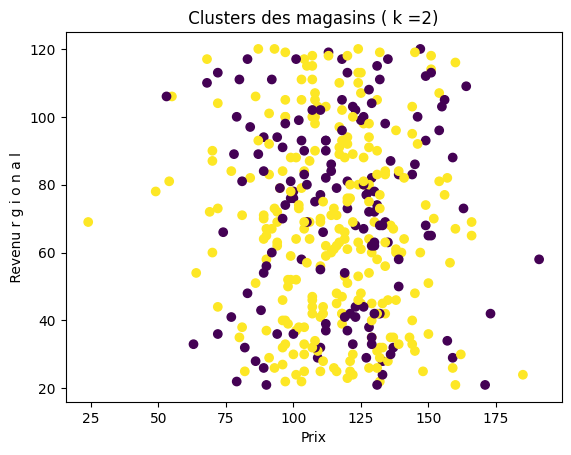

In [ ]:
plt . scatter ( df [ "Price" ] , df [ "Income" ] , c = df [ "Cluster" ])
plt . xlabel ( "Prix" )
plt . ylabel ( " Revenu r g i o n a l " )
plt . title ( " Clusters des magasins ( k =2) " )
plt . show ()
